In [14]:
# predict_labels.py

import pandas as pd
import joblib
import sklearn

# =============================================================================
# 1) LOAD THE SAVED DECISION TREE MODEL
# =============================================================================

MODEL_PATH = 'decision_tree_model.joblib'  # ← Ensure this matches where you saved it
clf = joblib.load(MODEL_PATH)

# =============================================================================
# 2) LOAD NEW DATA CSV (WITHOUT LABELS) FOR PREDICTION
# =============================================================================

INPUT_CSV = './training_data/11_06_2025_device_5.csv'       # ← Replace with your input CSV path
OUTPUT_CSV = '11_06_2025_device_5____labeled.csv'    # ← Desired output path

df_new = pd.read_csv(INPUT_CSV)
print(df_new)

# If there are any columns not used in training (e.g., "Timestamp"), drop them:
# You must supply exactly the same numeric feature columns that the model was trained on.
# Example: if the model used columns ['Steps','Pam Score','Feature3',...], ensure df_new has those.
FEATURE_COLUMNS = clf.feature_names_in_.tolist() if hasattr(clf, 'feature_names_in_') else df_new.drop(columns=[], errors='ignore').select_dtypes(include='number').columns.tolist()

# Filter DataFrame to only the needed feature columns:
X_new = df_new[FEATURE_COLUMNS].copy()

# =============================================================================
# 3) MAKE PREDICTIONS
# =============================================================================

pred_labels = clf.predict(X_new)

# Optionally, get prediction probabilities:
# pred_probs = clf.predict_proba(X_new)
# You could add these as separate columns if desired.

# =============================================================================
# 4) APPEND PREDICTIONS TO DATAFRAME AND SAVE
# =============================================================================

df_new['predicted_tabel'] = pred_labels
df_new.to_csv(OUTPUT_CSV, index=False)
print(f"Predicted labels added and saved to '{OUTPUT_CSV}'")


print(df_new)


                Timestamp  Steps  PAM Score
0     2025-06-04 13:59:00     48     6.0000
1     2025-06-04 14:00:00     21     2.9375
2     2025-06-04 14:01:00     39     2.7500
3     2025-06-04 14:05:00      6     0.7500
4     2025-06-04 14:06:00     63     4.5000
...                   ...    ...        ...
2305  2025-06-11 10:24:00      0     0.1875
2306  2025-06-11 10:25:00      0     0.0625
2307  2025-06-11 10:26:00      3     0.1875
2308  2025-06-11 10:27:00     17     2.1875
2309  2025-06-11 10:28:00     10     0.5625

[2310 rows x 3 columns]
Predicted labels added and saved to '11_06_2025_device_5____labeled.csv'
                Timestamp  Steps  PAM Score  predicted_tabel
0     2025-06-04 13:59:00     48     6.0000                0
1     2025-06-04 14:00:00     21     2.9375                2
2     2025-06-04 14:01:00     39     2.7500                2
3     2025-06-04 14:05:00      6     0.7500                1
4     2025-06-04 14:06:00     63     4.5000                0
...     

Predicted labels added and saved to '11_06_2025_device_5____labeled.csv'


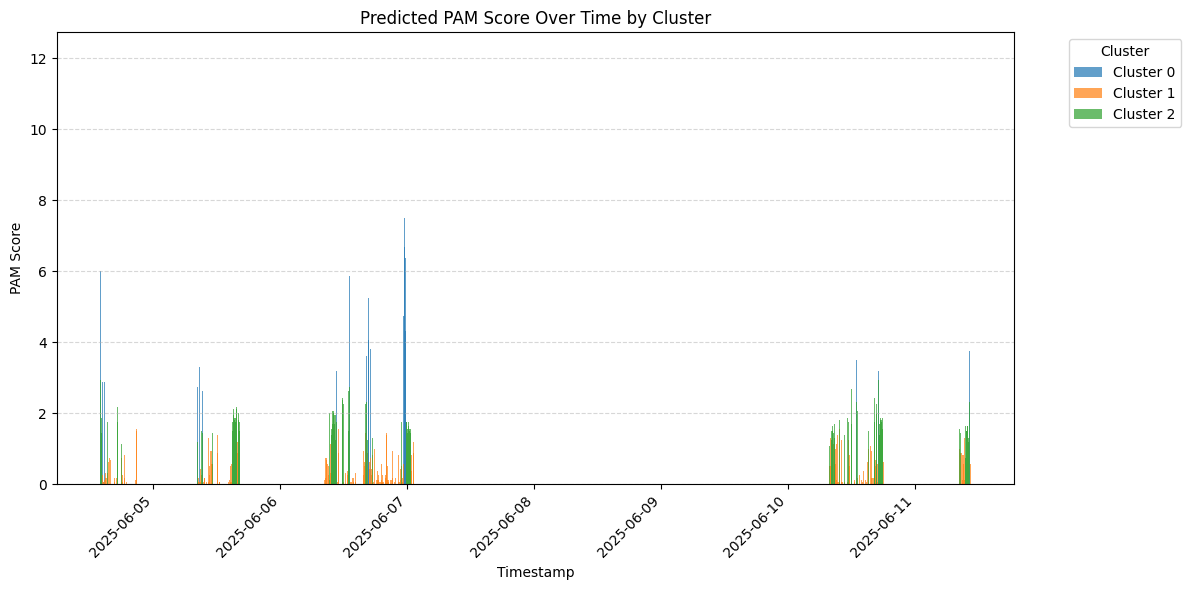

In [15]:

import matplotlib.pyplot as plt
# =============================================================================
# 5) SAVE THE LABELED DATA
# =============================================================================

df_new.to_csv(OUTPUT_CSV, index=False)
print(f"Predicted labels added and saved to '{OUTPUT_CSV}'")

# =============================================================================
# 6) PLOT BAR CHART: PAM SCORE OVER TIME, COLORED BY PREDICTED CLUSTER
# =============================================================================

# If there's a Timestamp column, parse it:
if 'Timestamp' in df_new.columns:
    df_new['Timestamp'] = pd.to_datetime(df_new['Timestamp'], errors='coerce')
else:
    # If no timestamp, you could use the row index or another time column—here we just error out.
    raise ValueError("No 'Timestamp' column found for plotting.")

# We'll plot 'PAM Score' on the y-axis; adjust name if different
if 'PAM Score' not in df_new.columns:
    raise ValueError("No 'PAM Score' column found for plotting.")

# Only plot rows that have valid timestamps
plot_df = df_new.dropna(subset=['Timestamp'])

plt.figure(figsize=(12, 6))

# Choose a narrow bar width (e.g. 2 minutes)
bar_width = pd.Timedelta(minutes=2)

for cluster_label in sorted(plot_df['predicted_tabel'].unique()):
    mask = plot_df['predicted_tabel'] == cluster_label
    plt.bar(
        plot_df.loc[mask, 'Timestamp'],
        plot_df.loc[mask, 'PAM Score'],
        width=bar_width,
        alpha=0.7,
        label=f'Cluster {cluster_label}'
    )

plt.xlabel('Timestamp')
plt.ylabel('PAM Score')
plt.title('Predicted PAM Score Over Time by Cluster')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

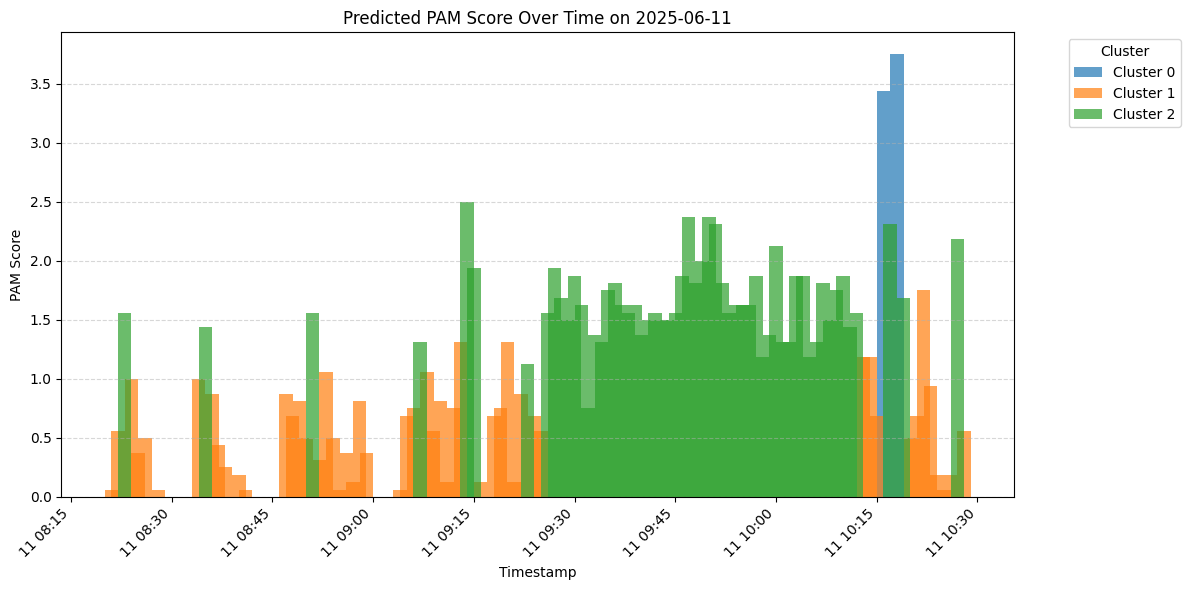

In [16]:
# =============================================================================
# 6) PLOT BAR CHART: PAM SCORE OVER LAST DAY, COLORED BY PREDICTED CLUSTER
# =============================================================================

# Parse 'Timestamp' and extract date
df_new['Timestamp'] = pd.to_datetime(df_new['Timestamp'], errors='coerce')
df_new['DateOnly'] = df_new['Timestamp'].dt.date

# Find the most recent date
last_date = df_new['DateOnly'].max()

# Filter to only that last day
plot_df = df_new[df_new['DateOnly'] == last_date].copy()

if plot_df.empty:
    raise ValueError(f"No data found for the last date ({last_date}) in `Timestamp`.")

plt.figure(figsize=(12, 6))

# Narrow bar width of ~2 minutes
bar_width = pd.Timedelta(minutes=2)

for cluster_label in sorted(plot_df['predicted_tabel'].unique()):
    mask = plot_df['predicted_tabel'] == cluster_label
    plt.bar(
        plot_df.loc[mask, 'Timestamp'],
        plot_df.loc[mask, 'PAM Score'],
        width=bar_width,
        alpha=0.7,
        label=f'Cluster {cluster_label}'
    )

plt.xlabel('Timestamp')
plt.ylabel('PAM Score')
plt.title(f'Predicted PAM Score Over Time on {last_date}')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


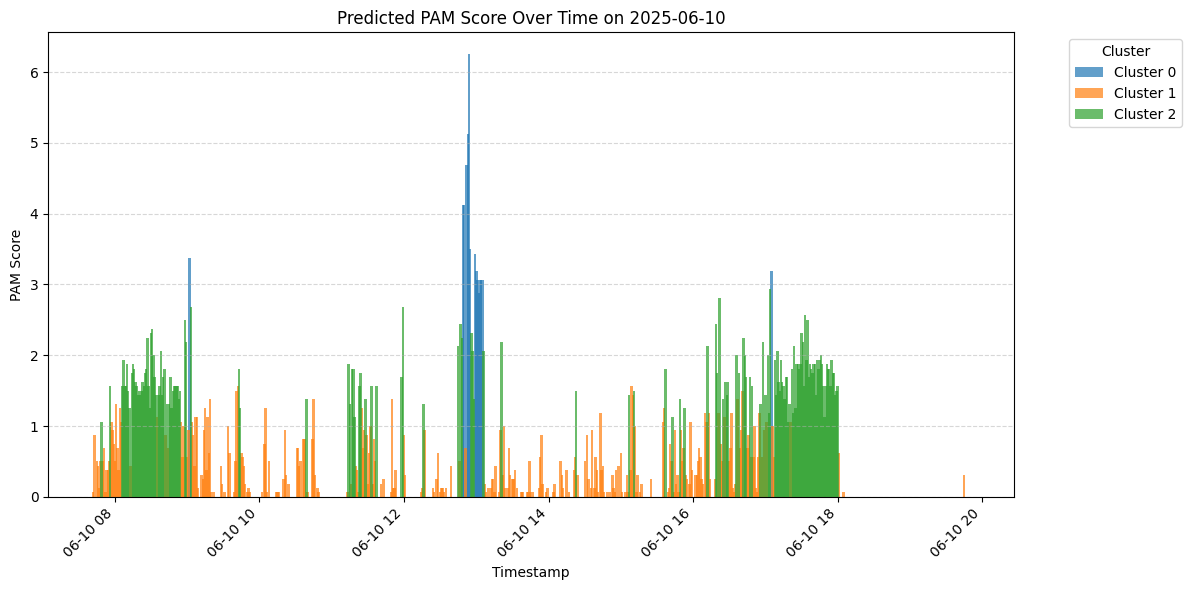

In [17]:
# =============================================================================
# PLOT BAR CHART: PAM SCORE OVER TIME ON THE DAY BEFORE THE LAST DATE
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Assuming df_new already has 'Timestamp', 'PAM Score', and 'predicted_tabel'

# Parse 'Timestamp' and extract date
df_new['Timestamp'] = pd.to_datetime(df_new['Timestamp'], errors='coerce')
df_new['DateOnly']  = df_new['Timestamp'].dt.date

# Determine the last date in the data
last_date = df_new['DateOnly'].max()
# Compute the day before that
day_before = last_date - timedelta(days=1)

# Filter to only that day
plot_df = df_new[df_new['DateOnly'] == day_before].copy()

if plot_df.empty:
    raise ValueError(f"No data found for the day before the last date ({day_before}).")

plt.figure(figsize=(12, 6))

# Choose a narrow bar width (e.g., 2 minutes)
bar_width = pd.Timedelta(minutes=2)

for cluster_label in sorted(plot_df['predicted_tabel'].unique()):
    mask = plot_df['predicted_tabel'] == cluster_label
    plt.bar(
        plot_df.loc[mask, 'Timestamp'],
        plot_df.loc[mask, 'PAM Score'],
        width=bar_width,
        alpha=0.7,
        label=f'Cluster {cluster_label}'
    )

plt.xlabel('Timestamp')
plt.ylabel('PAM Score')
plt.title(f'Predicted PAM Score Over Time on {day_before}')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
